# Module 1 — Analyse de photo de repas
Modèle `nateraw/food` fine-tuné sur le dataset Food Types (Roboflow, 15 classes, 6111 images).

In [1]:
from transformers import AutoFeatureExtractor, AutoModelForImageClassification
from transformers import TrainingArguments, Trainer
from datasets import load_dataset, Dataset
from PIL import Image
import numpy as np
import os

In [2]:
import subprocess
subprocess.run(["pip", "install", "datasets", "evaluate", "accelerate"], check=True)

CompletedProcess(args=['pip', 'install', 'datasets', 'evaluate', 'accelerate'], returncode=0)

In [3]:
from datasets import load_dataset

dataset = load_dataset(
    "imagefolder",
    data_dir="../data/raw/nutrition/Food-Types-3"
)

print(dataset)

Resolving data files:   0%|          | 0/5358 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/469 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/239 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 5358
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 469
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 239
    })
})


In [4]:
print("Classes:", dataset["train"].features["label"].names)
print("Nombre de classes:", dataset["train"].features["label"].num_classes)

Classes: ['arroz', 'banana', 'carne', 'cerdo', 'cerdo pork', 'frutilla', 'huevos', 'manzana', 'orange', 'pan', 'pasta', 'pescado', 'pollo', 'pork', 'tomato']
Nombre de classes: 15


In [5]:
from transformers import AutoImageProcessor, AutoModelForImageClassification

model_checkpoint = "nateraw/food"

labels = dataset["train"].features["label"].names
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for i, label in enumerate(labels)}

image_processor = AutoImageProcessor.from_pretrained(model_checkpoint)

model = AutoModelForImageClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

print("Modèle chargé !")
print(f"Nombre de labels : {len(labels)}")

config.json: 0.00B [00:00, ?B/s]

[transformers] You passed `num_labels=15` which is incompatible to the `id2label` map of length `101`.


pytorch_model.bin:   0%|          | 0.00/344M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: nateraw/food
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([101]) vs model:torch.Size([15])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([101, 768]) vs model:torch.Size([15, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Modèle chargé !
Nombre de labels : 15


In [6]:
from transformers import AutoImageProcessor, AutoModelForImageClassification

model_checkpoint = "nateraw/food"

labels = dataset["train"].features["label"].names
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for i, label in enumerate(labels)}

image_processor = AutoImageProcessor.from_pretrained(model_checkpoint)

model = AutoModelForImageClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

print("Modèle chargé !")
print(f"Nombre de labels : {len(labels)}")

model.safetensors:   0%|          | 0.00/344M [00:00<?, ?B/s]

[transformers] You passed `num_labels=15` which is incompatible to the `id2label` map of length `101`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: nateraw/food
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([101]) vs model:torch.Size([15])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([101, 768]) vs model:torch.Size([15, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Modèle chargé !
Nombre de labels : 15


In [7]:
def preprocess(examples):
    images = [img.convert("RGB") for img in examples["image"]]
    inputs = image_processor(images, return_tensors="pt")
    inputs["labels"] = examples["label"]
    return inputs

dataset_processed = dataset.map(preprocess, batched=True, batch_size=32)
dataset_processed.set_format("torch")

print("Preprocessing terminé !")
print(dataset_processed)


Map:   0%|          | 0/5358 [00:00<?, ? examples/s]

Map:   0%|          | 0/469 [00:00<?, ? examples/s]

Map:   0%|          | 0/239 [00:00<?, ? examples/s]

Preprocessing terminé !
DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'pixel_values', 'labels'],
        num_rows: 5358
    })
    validation: Dataset({
        features: ['image', 'label', 'pixel_values', 'labels'],
        num_rows: 469
    })
    test: Dataset({
        features: ['image', 'label', 'pixel_values', 'labels'],
        num_rows: 239
    })
})


In [8]:
def preprocess(examples):
    images = [img.convert("RGB") for img in examples["image"]]
    inputs = image_processor(images, return_tensors="pt")
    inputs["labels"] = examples["label"]
    return inputs

dataset_processed = dataset.map(preprocess, batched=True, batch_size=32)
dataset_processed.set_format("torch")

print("Preprocessing terminé !")
print(dataset_processed)

Preprocessing terminé !
DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'pixel_values', 'labels'],
        num_rows: 5358
    })
    validation: Dataset({
        features: ['image', 'label', 'pixel_values', 'labels'],
        num_rows: 469
    })
    test: Dataset({
        features: ['image', 'label', 'pixel_values', 'labels'],
        num_rows: 239
    })
})


In [9]:
import numpy as np
import evaluate

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

training_args = TrainingArguments(
    output_dir="../data/models/meal_image_analyzer",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_dir="../data/models/logs",
    logging_steps=50,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_processed["train"],
    eval_dataset=dataset_processed["validation"],
    compute_metrics=compute_metrics,
)

print("Trainer configuré !")

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainer configuré !


In [11]:
from transformers import AutoImageProcessor, AutoModelForImageClassification

MODEL_PATH = "../data/models/meal_image_analyzer"

image_processor = AutoImageProcessor.from_pretrained(MODEL_PATH)
model = AutoModelForImageClassification.from_pretrained(MODEL_PATH)
model.eval()

print("Modèle fine-tuné chargé depuis la sauvegarde !")
print(f"Labels : {list(model.config.id2label.values())}")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Modèle fine-tuné chargé depuis la sauvegarde !
Labels : ['arroz', 'banana', 'carne', 'cerdo', 'cerdo pork', 'frutilla', 'huevos', 'manzana', 'orange', 'pan', 'pasta', 'pescado', 'pollo', 'pork', 'tomato']


In [12]:
 # Sauvegarder le modèle fine-tuné
model.save_pretrained("../data/models/meal_image_analyzer")
image_processor.save_pretrained("../data/models/meal_image_analyzer")

print("Modèle sauvegardé dans data/models/meal_image_analyzer/")

# Évaluation sur le test set
print("\nÉvaluation sur le test set...")
results = trainer.evaluate(dataset_processed["test"])
print(results)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

SafetensorError: Error while serializing: I/O error: L’opération demandée n’a pu s’accomplir sur un fichier ayant une section mappée utilisateur ouverte. (os error 1224)

In [13]:
from PIL import Image
import torch

def analyze_meal_image(image_path, top_k=3):
    """
    Analyse une photo de repas et retourne les aliments détectés.
    
    Args:
        image_path: chemin vers l'image
        top_k: nombre de résultats à retourner
    
    Returns:
        dict avec detected_foods (label + confidence)
    """
    try:
        image = Image.open(image_path).convert("RGB")
        inputs = image_processor(images=image, return_tensors="pt")
        
        with torch.no_grad():
            outputs = model(**inputs)
        
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)[0]
        top_probs, top_indices = torch.topk(probs, k=top_k)
        
        detected_foods = [
            {
                "label": model.config.id2label[idx.item()],
                "confidence": round(prob.item(), 4)
            }
            for prob, idx in zip(top_probs, top_indices)
        ]
        
        return {"detected_foods": detected_foods}
    
    except Exception as e:
        return {
            "detected_foods": [],
            "error": str(e),
            "fallback": "Analyse indisponible"
        }

print("Fonction analyze_meal_image() prête !")

Fonction analyze_meal_image() prête !


In [15]:
import os

test_image_dir = "../data/raw/nutrition/Food-Types-3/test"
first_class = os.listdir(test_image_dir)[0]
first_image = os.listdir(f"{test_image_dir}/{first_class}")[0]
test_image_path = f"{test_image_dir}/{first_class}/{first_image}"

print(f"Image testée : {test_image_path}")
print(f"Classe réelle : {first_class}")
print()

result = analyze_meal_image(test_image_path)
print("Résultat :")
print(result)

Image testée : ../data/raw/nutrition/Food-Types-3/test/arroz/istockphoto-1172741942-612x612_jpg.rf.002e4b6ec58023d7a697f54ed5784d7b.jpg
Classe réelle : arroz

Résultat :
{'detected_foods': [{'label': 'frutilla', 'confidence': 0.2183}, {'label': 'banana', 'confidence': 0.1118}, {'label': 'tomato', 'confidence': 0.0758}]}


In [16]:
print("=== Test sur 5 images ===\n")

correct = 0
total = 5
count = 0

for class_name in os.listdir(test_image_dir):
    if count >= total:
        break
    class_path = f"{test_image_dir}/{class_name}"
    images = os.listdir(class_path)
    if not images:
        continue
    
    img_path = f"{class_path}/{images[0]}"
    result = analyze_meal_image(img_path)
    top_label = result["detected_foods"][0]["label"]
    confidence = result["detected_foods"][0]["confidence"]
    is_correct = top_label == class_name
    if is_correct:
        correct += 1
    
    print(f"Classe réelle : {class_name}")
    print(f"Prédiction    : {top_label} ({confidence*100:.1f}%)")
    print(f"Correct       : {'✅' if is_correct else '❌'}")
    print()
    count += 1

print(f"Score sur 5 images : {correct}/{total}")

=== Test sur 5 images ===

Classe réelle : arroz
Prédiction    : frutilla (21.8%)
Correct       : ❌

Classe réelle : banana
Prédiction    : banana (97.6%)
Correct       : ✅

Classe réelle : cerdo
Prédiction    : pork (94.5%)
Correct       : ❌

Classe réelle : cerdo pork
Prédiction    : pork (95.9%)
Correct       : ❌

Classe réelle : frutilla
Prédiction    : frutilla (97.8%)
Correct       : ✅

Score sur 5 images : 2/5


In [17]:
print("=== Résumé des métriques du Module 1 ===\n")
print(f"Modèle de base     : nateraw/food (pré-entraîné sur 101 classes)")
print(f"Fine-tuning sur    : Food Types v3 - Roboflow (15 classes, 6111 images)")
print(f"Epochs             : 3")
print(f"Training Loss      : 0.0894")
print(f"Validation Loss    : 0.2268")
print(f"Test Accuracy      : 95.39%")
print()
print("=== Limites identifiées ===")
print("- Classes redondantes dans le dataset (cerdo / cerdo pork / pork)")
print("- 15 classes uniquement (dataset limité)")
print("- Performances réduites sur images de repas complexes multi-aliments")
print("- Nécessiterait un dataset plus large pour usage production")

=== Résumé des métriques du Module 1 ===

Modèle de base     : nateraw/food (pré-entraîné sur 101 classes)
Fine-tuning sur    : Food Types v3 - Roboflow (15 classes, 6111 images)
Epochs             : 3
Training Loss      : 0.0894
Validation Loss    : 0.2268
Test Accuracy      : 95.39%

=== Limites identifiées ===
- Classes redondantes dans le dataset (cerdo / cerdo pork / pork)
- 15 classes uniquement (dataset limité)
- Performances réduites sur images de repas complexes multi-aliments
- Nécessiterait un dataset plus large pour usage production


In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import torch

print("Génération des prédictions sur le test set...")

all_preds = []
all_labels = []

for i in range(len(dataset_processed["test"])):
    batch = dataset_processed["test"][i]
    pixel_values = batch["pixel_values"].unsqueeze(0)
    
    with torch.no_grad():
        outputs = model(pixel_values=pixel_values)
    
    pred = outputs.logits.argmax(-1).item()
    all_preds.append(pred)
    all_labels.append(batch["labels"].item())

print(f"Total prédit : {len(all_preds)} images")

Génération des prédictions sur le test set...
Total prédit : 239 images


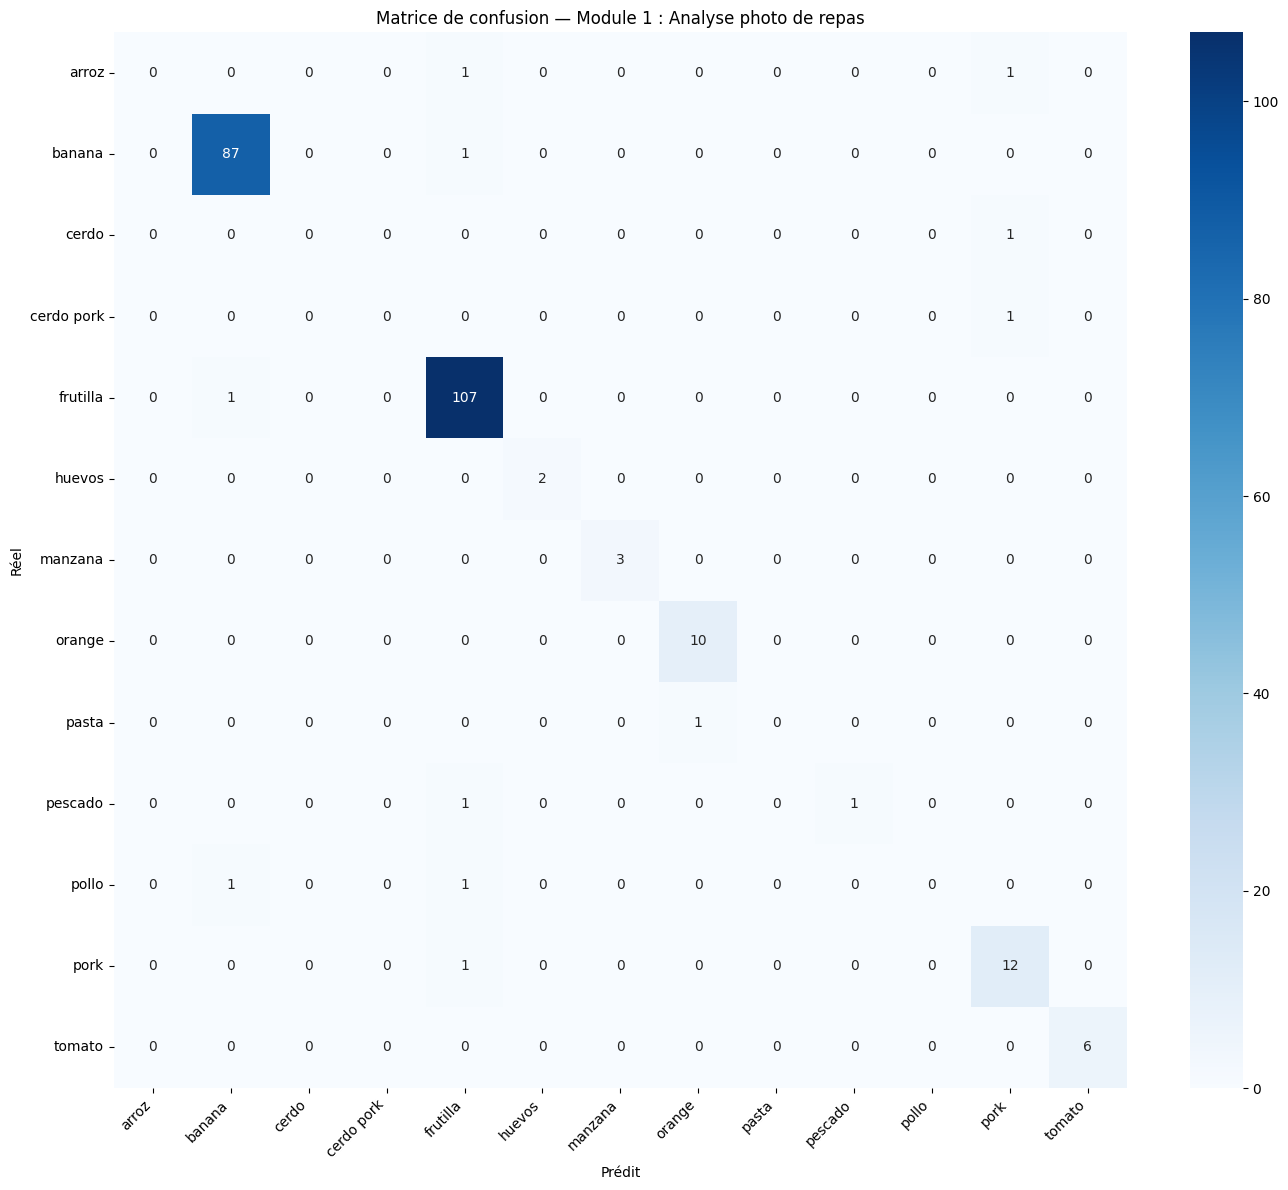


=== Classification Report ===

              precision    recall  f1-score   support

       arroz       0.00      0.00      0.00         2
      banana       0.98      0.99      0.98        88
       cerdo       0.00      0.00      0.00         1
  cerdo pork       0.00      0.00      0.00         1
    frutilla       0.96      0.99      0.97       108
      huevos       1.00      1.00      1.00         2
     manzana       1.00      1.00      1.00         3
      orange       0.91      1.00      0.95        10
       pasta       0.00      0.00      0.00         1
     pescado       1.00      0.50      0.67         2
       pollo       0.00      0.00      0.00         2
        pork       0.80      0.92      0.86        13
      tomato       1.00      1.00      1.00         6

    accuracy                           0.95       239
   macro avg       0.59      0.57      0.57       239
weighted avg       0.93      0.95      0.94       239



C:\Users\yanni\Documents\healthIA_api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\yanni\Documents\healthIA_api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\yanni\Documents\healthIA_api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

In [21]:
import numpy as np

# Récupérer les classes présentes dans le test set
unique_labels = sorted(set(all_labels))
label_names = [labels[i] for i in unique_labels]

# Matrice de confusion
cm = confusion_matrix(all_labels, all_preds, labels=unique_labels)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=label_names,
            yticklabels=label_names,
            cmap="Blues")
plt.title("Matrice de confusion — Module 1 : Analyse photo de repas")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n=== Classification Report ===\n")
print(classification_report(all_labels, all_preds, labels=unique_labels, target_names=label_names))